In [12]:
import pandas as pd
import ast
import random
import matplotlib.pyplot as plt

In [13]:
recipes = pd.read_csv("data/recipes_cleaned.csv")

In [14]:
recipes.head()

,Name,RecipeIngredientParts,AggregatedRating,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeInstructions,TotalTimeMinutes
0,Low-Fat Berry Blue Frozen Dessert,"['blueberries', 'granulated sugar', 'vanilla y...",4.5,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2,"['Toss 2 cups berries with sugar.', 'Let stand...",1485
1,Biryani,"['saffron', 'milk', 'hot green chili peppers',...",3.0,1110.7,58.8,16.6,372.8,368.4,84.4,9.0,20.4,63.4,['Soak saffron in warm milk for 5 minutes and ...,265
2,Best Lemonade,"['sugar', 'lemons, rind of', 'lemon, zest of',...",4.5,311.1,0.2,0.0,0.0,1.8,81.5,0.4,77.2,0.3,"['Into a 1 quart Jar with tight fitting lid, p...",35
3,Carina's Tofu-Vegetable Kebabs,"['extra firm tofu', 'eggplant', 'zucchini', 'm...",4.5,536.1,24.0,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,"['Drain the tofu, carefully squeezing out exce...",1460
4,Cabbage Soup,"['plain tomato juice', 'cabbage', 'onion', 'ca...",4.5,103.6,0.4,0.1,0.0,959.3,25.1,4.8,17.7,4.3,['Mix everything together and bring to a boil....,50


In [15]:
recipes['RecipeIngredientParts'] = recipes['RecipeIngredientParts'].apply(
    lambda x: ast.literal_eval(x) 
)

In [16]:
# recipes['RecipeInstructions'] = recipes['RecipeInstructions'].apply(
#     lambda x: ast.literal_eval(x)
# )

In [17]:
recipe_json = recipes.to_dict(orient='records')

In [18]:
# ---------- Фитнес-функция ----------
def fitness_indexed(individual, recipe_list, available_ingredients, max_total_time, nutrition_targets):
    total_score = 0
    total_time = 0
    total_nutrition = {key: 0 for key in nutrition_targets}

    for idx in individual:
        recipe = recipe_list[idx]
        ingredients = recipe['RecipeIngredientParts']
        matches = sum(1 for ing in ingredients if any(a.lower() in ing.lower() for a in available_ingredients))
        ingredient_score = matches / len(ingredients) if ingredients else 0

        rating = recipe['AggregatedRating']
        rating_score = rating / 5.0 if rating > 0 else 0

        for feature in nutrition_targets:
            total_nutrition[feature] += recipe.get(feature, 0)

        total_score += ingredient_score * 0.6 + rating_score * 0.3
        total_time += recipe['TotalTimeMinutes']

    # Penalty calculations
    penalty = 0
    if total_time > max_total_time:
        penalty += 0.3 * (total_time - max_total_time) / max_total_time

    for k, v in nutrition_targets.items():
        actual = total_nutrition[k]
        penalty += 0.3 * abs(actual - v) / v

    avg_score = total_score / len(individual) if individual else 0
    return avg_score - penalty

# ---------- Кроссовер ----------
def crossover_indexed(p1, p2, min_r, max_r):
    combined = list(dict.fromkeys(p1 + p2))  # Уникальные индексы
    k = min(len(combined), random.randint(min_r, max_r))
    return random.sample(combined, k)

# ---------- Мутация ----------
def mutate_indexed(individual, total_recipes, min_r, max_r, mutation_rate=0.2):
    new_ind = individual[:]

    if random.random() < mutation_rate:
        i = random.randint(0, len(new_ind) - 1)
        new_ind[i] = random.randint(0, total_recipes - 1)

    if len(new_ind) < max_r and random.random() < mutation_rate / 2:
        new_ind.append(random.randint(0, total_recipes - 1))

    if len(new_ind) > min_r and random.random() < mutation_rate / 2:
        del new_ind[random.randint(0, len(new_ind) - 1)]

    return list(dict.fromkeys(new_ind))  # Удаляем дубликаты

# ---------- Генетический алгоритм ----------
def genetic_algorithm_optimized_indexed(
    recipe_list, available_ingredients, max_total_time, nutrition_targets,
    population_size=50, generations=500, mutation_rate=0.7,
    min_recipes=2, max_recipes=5
):
    total_recipes = len(recipe_list)

    # Индивиды = списки индексов
    population = [
        random.sample(range(total_recipes), random.randint(min_recipes, max_recipes))
        for _ in range(population_size)
    ]
    history = []
    for _ in range(generations):
        scored_population = [
            (ind, fitness_indexed(ind, recipe_list, available_ingredients, max_total_time, nutrition_targets))
            for ind in population
        ]
        scored_population.sort(key=lambda x: x[1], reverse=True)
        top = [ind for ind, _ in scored_population[:population_size // 2]]
        history.append(scored_population[0][1])

        children = []
        for _ in range(population_size // 2):
            p1, p2 = random.sample(top, 2)
            child = crossover_indexed(p1, p2, min_recipes, max_recipes)
            child = mutate_indexed(child, total_recipes, min_recipes, max_recipes, mutation_rate)
            children.append(child)

        population = top + children

    best = max(population, key=lambda ind: fitness_indexed(ind, recipe_list, available_ingredients, max_total_time, nutrition_targets))
    return [recipe_list[i] for i in best], history

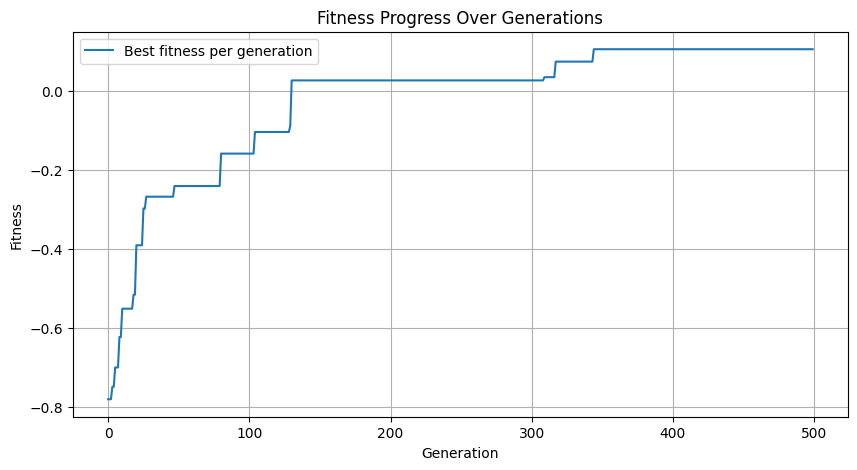

In [19]:
best_solution, fitness_history = genetic_algorithm_optimized_indexed(
    recipe_json,  # DataFrame с рецептами
    available_ingredients = ["chicken", "egg", "milk"],
    max_total_time = 120, # минут
    nutrition_targets = {
        'Calories': 1800,
        'FatContent': 0.35*1800,
        'SugarContent': 30,
        'SodiumContent': 230,
        'ProteinContent': 180
    }
)

plt.figure(figsize=(10, 5))
plt.plot(fitness_history, label='Best fitness per generation')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness Progress Over Generations')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
best_solution

[{'Name': 'Homemade Wood Furniture Polish',
  'RecipeIngredientParts': ['olive oil', 'lemon juice'],
  'AggregatedRating': 5.0,
  'Calories': 1290.8,
  'FatContent': 144.2,
  'SaturatedFatContent': 19.9,
  'CholesterolContent': 0.0,
  'SodiumContent': 3.7,
  'CarbohydrateContent': 5.6,
  'FiberContent': 0.2,
  'SugarContent': 2.0,
  'ProteinContent': 0.3,
  'RecipeInstructions': "['Use flannel wood polish cloths.']",
  'TotalTimeMinutes': 2},
 {'Name': 'Chocolate Orange Fudge',
  'RecipeIngredientParts': ['sweetened condensed milk'],
  'AggregatedRating': 5.0,
  'Calories': 102.8,
  'FatContent': 5.5,
  'SaturatedFatContent': 2.8,
  'CholesterolContent': 3.8,
  'SodiumContent': 21.8,
  'CarbohydrateContent': 13.7,
  'FiberContent': 0.9,
  'SugarContent': 12.4,
  'ProteinContent': 1.8,
  'RecipeInstructions': "['In med.', 'pan, melt chips and milk.', 'Remove from heat, stir in nuts and orange peel.', 'Pour into buttered 8inch square pan.', 'Cool for 15 minutes, then cover and chill for 